In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

In [4]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=5, shuffle=False)

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s] 


In [5]:
class EncoderDecoder(nn.Module):
    def __init__(self):
        super(EncoderDecoder, self).__init__()
        
        # Encoder: Compress the image
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1), # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 16x16 -> 8x8
            nn.ReLU(),
        )
        
        # Decoder: Reconstruct the image
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16 -> 32x32
            nn.Tanh() # Outputs values in [-1, 1], matching our normalization!
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [6]:
model = EncoderDecoder().to(device)

In [7]:
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
num_epochs = 5 # Kept short for quick Colab testing
print("Starting Training...")

for epoch in range(num_epochs):
    running_loss = 0.0
    for data in train_loader:
        img, _ = data 
        # For our baseline paired task, input is the image, and target is the SAME image (Reconstruction)
        img = img.to(device)
        
        # Forward pass
        output = model(img)
        loss = criterion(output, img) # MSE Loss
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

Starting Training...
Epoch [1/5], Loss: 0.0274
Epoch [2/5], Loss: 0.0058
Epoch [3/5], Loss: 0.0037
Epoch [4/5], Loss: 0.0028
Epoch [5/5], Loss: 0.0023


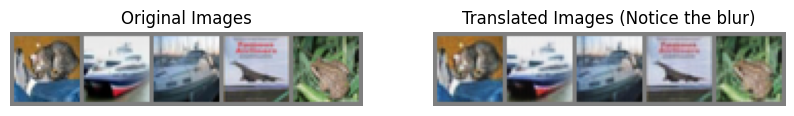

In [9]:
def imshow(img, title):
    # Un-normalize from [-1, 1] back to [0, 1] for displaying
    img = img / 2 + 0.5 
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

model.eval()
with torch.no_grad():
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)
    
    outputs = model(images)
    
    # Plot Original vs Translated (Reconstructed)
    plt.figure(figsize=(10, 4))
    
    # Original Images
    plt.subplot(1, 2, 1)
    imshow(torchvision.utils.make_grid(images.cpu()), "Original Images")
    
    # Translated/Reconstructed Images
    plt.subplot(1, 2, 2)
    # As you will see, these will look blurry compared to the originals!
    imshow(torchvision.utils.make_grid(outputs.cpu()), "Translated Images (Notice the blur)") 
    
    plt.show()